In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
main_df = pd.read_csv('https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv')
main_df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
main_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [4]:
main_df.isna().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [5]:
main_df['species'].value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

In [6]:
pd.DataFrame(main_df.groupby('species').mean())

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.006,3.428,1.462,0.246
versicolor,5.936,2.770,4.260,1.326
virginica,6.588,2.974,5.552,2.026


In [7]:
pd.DataFrame(main_df.groupby('species').min())

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,4.3,2.3,1.0,0.1
versicolor,4.9,2.0,3.0,1.0
virginica,4.9,2.2,4.5,1.4


In [8]:
pd.DataFrame(main_df.groupby('species').max())

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.8,4.4,1.9,0.6
versicolor,7.0,3.4,5.1,1.8
virginica,7.9,3.8,6.9,2.5


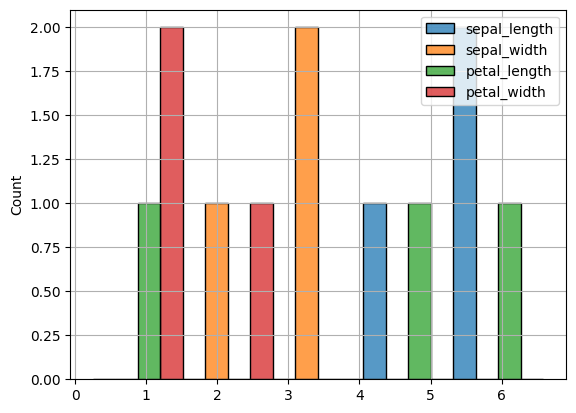

In [9]:
sns.histplot(data=main_df.groupby('species').mean(),multiple='dodge' )
plt.grid()

In [10]:
mean_df = pd.DataFrame(main_df.groupby('species').mean())

<Axes: xlabel='species', ylabel='sepal_length'>

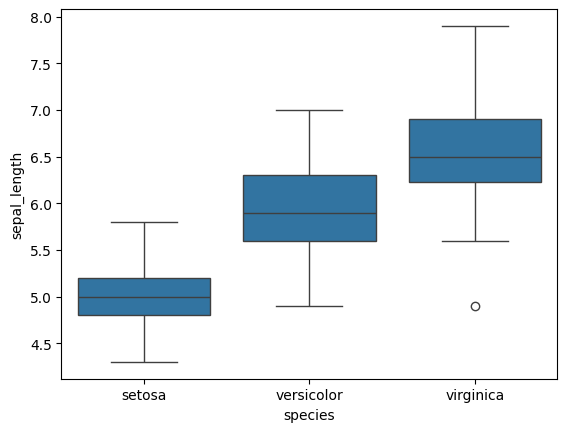

In [11]:
sns.boxplot(data=main_df,x='species',y='sepal_length')

<Axes: xlabel='species', ylabel='sepal_width'>

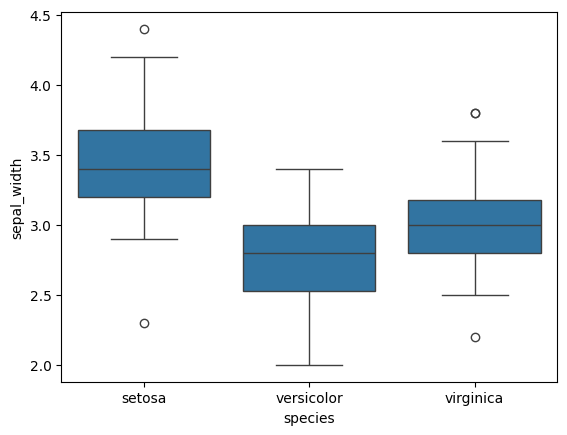

In [12]:
sns.boxplot(data=main_df,x='species',y='sepal_width')

/tmp/ipykernel_13268/1305877876.py:2: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


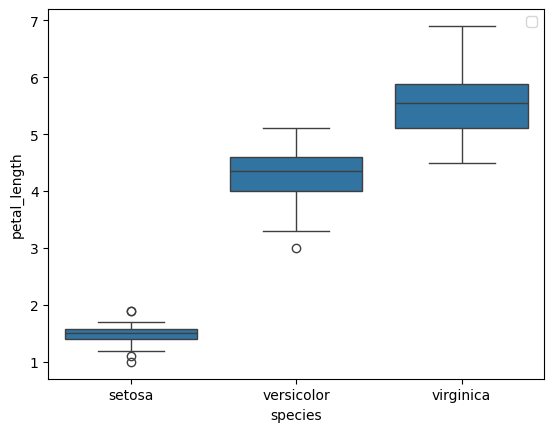

In [13]:
sns.boxplot(data=main_df,x='species',y='petal_length')
plt.legend()

<Axes: xlabel='species', ylabel='petal_width'>

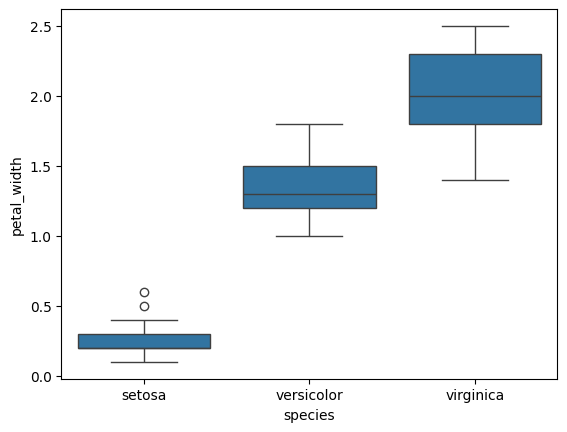

In [14]:
sns.boxplot(data=main_df,x='species',y='petal_width')

In [16]:
train_df1 = main_df.copy()

In [23]:
train_df1.describe()

,sepal_length,sepal_width,petal_length,petal_width,species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [18]:
train_df1['species'] = train_df1['species'].map({
    'setosa': 0,
    'versicolor': 1,
    'virginica': 2
})

In [19]:
train_df1.corr()['species']

sepal_length    0.782561
sepal_width    -0.426658
petal_length    0.949035
petal_width     0.956547
species         1.000000
Name: species, dtype: float64

<Axes: >

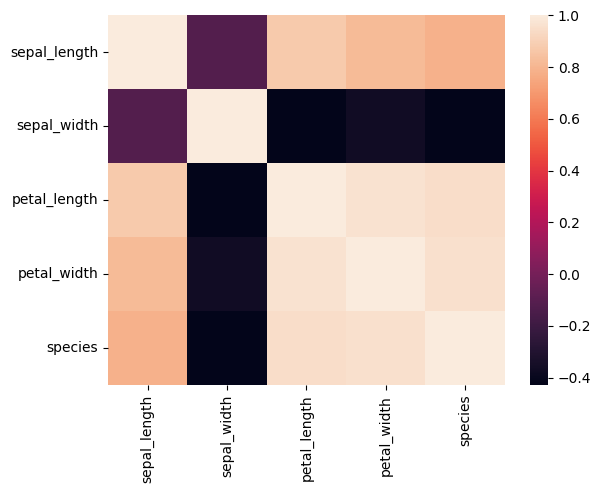

In [20]:
sns.heatmap(data=train_df1.corr())

In [21]:
train_df1.corr()['sepal_length']

sepal_length    1.000000
sepal_width    -0.117570
petal_length    0.871754
petal_width     0.817941
species         0.782561
Name: sepal_length, dtype: float64

<Axes: xlabel='sepal_length', ylabel='Count'>

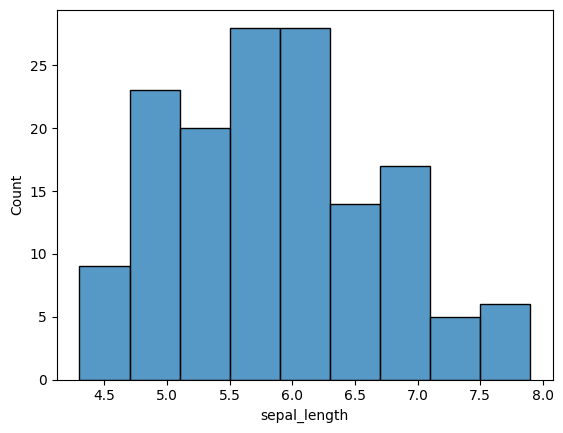

In [22]:
sns.histplot(data=train_df1,x='sepal_length')

<Axes: xlabel='sepal_width', ylabel='Count'>

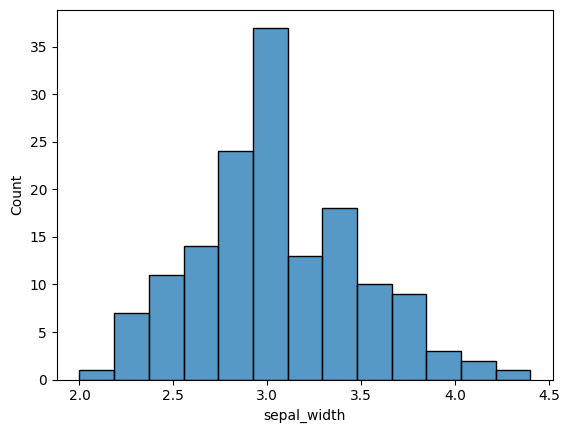

In [24]:
sns.histplot(data=train_df1,x='sepal_width')

<Axes: xlabel='petal_width', ylabel='Count'>

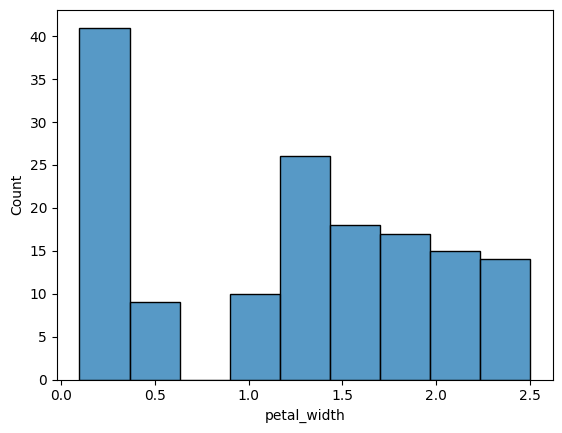

In [25]:
sns.histplot(data=train_df1,x='petal_width')

<Axes: xlabel='petal_length', ylabel='Count'>

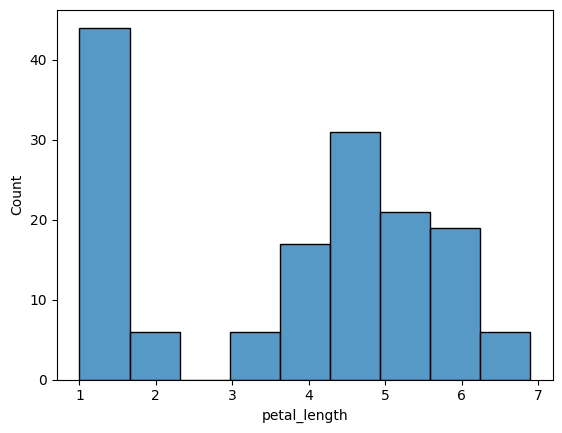

In [26]:
sns.histplot(data=train_df1,x='petal_length')

In [27]:
train_df1['length\width'] = train_df1['sepal_length']/train_df['sepal_width']

In [29]:
train_df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [30]:
from sklearn.model_selection import train_test_split

In [39]:
train_df,test_df =train_test_split(train_df1)

In [40]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 112 entries, 131 to 75
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  112 non-null    float64
 1   sepal_width   112 non-null    float64
 2   petal_length  112 non-null    float64
 3   petal_width   112 non-null    float64
 4   species       112 non-null    int64  
 5   length\width  112 non-null    float64
dtypes: float64(5), int64(1)
memory usage: 6.1 KB


In [41]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 38 entries, 47 to 119
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  38 non-null     float64
 1   sepal_width   38 non-null     float64
 2   petal_length  38 non-null     float64
 3   petal_width   38 non-null     float64
 4   species       38 non-null     int64  
 5   length\width  38 non-null     float64
dtypes: float64(5), int64(1)
memory usage: 2.1 KB


In [42]:
train_df.isna().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
length\width    0
dtype: int64

In [43]:
test_df.isna().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
length\width    0
dtype: int64

In [44]:
train_df.describe()

,sepal_length,sepal_width,petal_length,petal_width,species,length\width
count,112.000000,112.000000,112.000000,112.000000,112.000000,112.000000
mean,5.879464,3.046429,3.833036,1.232143,1.035714,1.972771
std,0.828995,0.444775,1.745181,0.740734,0.815708,0.397351
min,4.300000,2.000000,1.000000,0.100000,0.000000,1.268293
25%,5.100000,2.800000,1.600000,0.375000,0.000000,1.558972
50%,5.900000,3.000000,4.450000,1.400000,1.000000,2.037857
75%,6.400000,3.300000,5.100000,1.800000,2.000000,2.233333
max,7.900000,4.400000,6.900000,2.500000,2.000000,2.961538


In [45]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 112 entries, 131 to 75
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  112 non-null    float64
 1   sepal_width   112 non-null    float64
 2   petal_length  112 non-null    float64
 3   petal_width   112 non-null    float64
 4   species       112 non-null    int64  
 5   length\width  112 non-null    float64
dtypes: float64(5), int64(1)
memory usage: 6.1 KB


In [46]:
test_df.isna().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
length\width    0
dtype: int64

In [48]:
x_train = train_df.drop(columns=['species'])
y_train = train_df['species']
x_test = test_df.drop(columns=['species'])
y_test = test_df['species']

In [49]:
from sklearn.ensemble import RandomForestClassifier

In [50]:
rf_model = RandomForestClassifier()

In [52]:
rf_model.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [53]:
from sklearn.metrics import accuracy_score,classification_report,f1_score,recall_score

In [71]:
def model_evulator(x_matrix, y_matrix, model):
    preds = model.predict(x_matrix)
    print('********************')
    print(f'\n,\n accuracy_score : {accuracy_score(y_true=y_matrix, y_pred=preds)}')
    print(f'f1 score : {f1_score(y_true=y_matrix, y_pred=preds, average="macro")}')
    print(f'recall_score : {recall_score(y_true=y_matrix, y_pred=preds, average="macro")}')
    print(f'classification_report :\n{classification_report(y_true=y_matrix, y_pred=preds)}')


In [72]:
model_evulator(x_train,y_train,rf_model)

********************

,
 accuracy_score : 1.0
f1 score : 1.0
recall_score : 1.0
classification_report :
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        35
           1       1.00      1.00      1.00        38
           2       1.00      1.00      1.00        39

    accuracy                           1.00       112
   macro avg       1.00      1.00      1.00       112
weighted avg       1.00      1.00      1.00       112



In [73]:
model_evulator(x_test,y_test,rf_model)

********************

,
 accuracy_score : 0.9736842105263158
f1 score : 0.9707936507936509
recall_score : 0.9696969696969697
classification_report :
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       0.92      1.00      0.96        12
           2       1.00      0.91      0.95        11

    accuracy                           0.97        38
   macro avg       0.97      0.97      0.97        38
weighted avg       0.98      0.97      0.97        38



In [74]:
np.round(pd.DataFrame(rf_model.feature_importances_,rf_model.feature_names_in_)*100,2).sort_values(by=0,ascending=False)

,0
petal_width,40.15
petal_length,30.40
length\width,16.03
sepal_length,10.13
sepal_width,3.29


In [76]:
hyperparamters_dict = {
    'criterion' :['gini','entropy'],
    'n_estimators':[50,100,150],
    'max_depth' : [None,5,10],
    'min_samples_split' : [2,5,10],
    'min_samples_leaf' :[2,4,6]
}


In [77]:
from sklearn.model_selection import GridSearchCV

In [78]:
GridSearchCVm = GridSearchCV(
    estimator=RandomForestClassifier(),
    param_grid=hyperparamters_dict,
    scoring='accuracy',
    verbose=3
)

In [79]:
GridSearchCVm.fit(x_train,y_train)

Fitting 5 folds for each of 162 candidates, totalling 810 fits
[CV 1/5] END criterion=gini, max_depth=None, min_samples_leaf=2, min_samples_split=2, n_estimators=50;, score=1.000 total time=   0.1s
[CV 2/5] END criterion=gini, max_depth=None, min_samples_leaf=2, min_samples_split=2, n_estimators=50;, score=0.913 total time=   0.1s
[CV 3/5] END criterion=gini, max_depth=None, min_samples_leaf=2, min_samples_split=2, n_estimators=50;, score=0.909 total time=   0.1s
[CV 4/5] END criterion=gini, max_depth=None, min_samples_leaf=2, min_samples_split=2, n_estimators=50;, score=1.000 total time=   0.1s
[CV 5/5] END criterion=gini, max_depth=None, min_samples_leaf=2, min_samples_split=2, n_estimators=50;, score=0.864 total time=   0.1s
[CV 1/5] END criterion=gini, max_depth=None, min_samples_leaf=2, min_samples_split=2, n_estimators=100;, score=1.000 total time=   0.1s
[CV 2/5] END criterion=gini, max_depth=None, min_samples_leaf=2, min_samples_split=2, n_estimators=100;, score=0.913 total tim

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'max_depth': [None, 5, ...], 'min_samples_leaf': [2, 4, ...], 'min_samples_split': [2, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each f

In [80]:
model_evulator(x_train,y_train,GridSearchCVm)

********************

,
 accuracy_score : 0.9821428571428571
f1 score : 0.9826576576576577
recall_score : 0.9824561403508771
classification_report :
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        35
           1       1.00      0.95      0.97        38
           2       0.95      1.00      0.97        39

    accuracy                           0.98       112
   macro avg       0.98      0.98      0.98       112
weighted avg       0.98      0.98      0.98       112



In [81]:
model_evulator(x_test,y_test,GridSearchCVm)

********************

,
 accuracy_score : 0.9736842105263158
f1 score : 0.9707936507936509
recall_score : 0.9696969696969697
classification_report :
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       0.92      1.00      0.96        12
           2       1.00      0.91      0.95        11

    accuracy                           0.97        38
   macro avg       0.97      0.97      0.97        38
weighted avg       0.98      0.97      0.97        38



In [82]:
np.round(pd.DataFrame(GridSearchCVm.best_estimator_.feature_importances_,GridSearchCVm.feature_names_in_)*100,3).sort_values(0, ascending=False)


,0
petal_width,47.144
petal_length,34.175
length\width,10.437
sepal_length,7.031
sepal_width,1.214
